In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
print(data.head())


  Post_ID   Post_Date   Platform     Hashtag Content_Type     Region    Views  \
0  Post_1  2022-01-13     TikTok  #Challenge        Video         UK  4163464   
1  Post_2  2022-05-13  Instagram  #Education       Shorts      India  4155940   
2  Post_3  2022-01-07    Twitter  #Challenge        Video     Brazil  3666211   
3  Post_4  2022-12-05    YouTube  #Education       Shorts  Australia   917951   
4  Post_5  2023-03-23     TikTok      #Dance         Post     Brazil    64866   

    Likes  Shares  Comments Engagement_Level  
0  339431   53135     19346             High  
1  215240   65860     27239           Medium  
2  327143   39423     36223           Medium  
3  127125   11687     36806              Low  
4  171361   69581      6376           Medium  


In [33]:
# Create binary target: trending if Views > 1,000,000

threshold = 1_000_000

data['is_trending'] = (data['Views'] > threshold).astype(int)

# Views
# 50,0000   → False -0
# 2,00,0000  → True -1
# 80,0000   → False-0

print("\n\n data.columns\n\n",data.columns)

# Drop ID column if exists
if 'Post_ID' in data.columns:
    data = data.drop('Post_ID', axis=1)

print(data.head())



 data.columns

 Index(['Post_ID', 'Post_Date', 'Platform', 'Hashtag', 'Content_Type', 'Region',
       'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level',
       'is_trending'],
      dtype='object')
    Post_Date   Platform     Hashtag Content_Type     Region    Views   Likes  \
0  2022-01-13     TikTok  #Challenge        Video         UK  4163464  339431   
1  2022-05-13  Instagram  #Education       Shorts      India  4155940  215240   
2  2022-01-07    Twitter  #Challenge        Video     Brazil  3666211  327143   
3  2022-12-05    YouTube  #Education       Shorts  Australia   917951  127125   
4  2023-03-23     TikTok      #Dance         Post     Brazil    64866  171361   

   Shares  Comments Engagement_Level  is_trending  
0   53135     19346             High            1  
1   65860     27239           Medium            1  
2   39423     36223           Medium            1  
3   11687     36806              Low            0  
4   69581      6376           Medium       

In [34]:
# Prepare features and target
X = data.drop('is_trending', axis=1)
y = data['is_trending']

# Convert Post_Date (string) to datetime and extract date
X['Post_Date'] = pd.to_datetime(X['Post_Date'], errors='coerce')
X['Month'] = X['Post_Date'].dt.month
X['DayOfWeek'] = X['Post_Date'].dt.dayofweek
X = X.drop('Post_Date', axis=1)

print(X,"x")

       Platform     Hashtag Content_Type     Region    Views   Likes  Shares  \
0        TikTok  #Challenge        Video         UK  4163464  339431   53135   
1     Instagram  #Education       Shorts      India  4155940  215240   65860   
2       Twitter  #Challenge        Video     Brazil  3666211  327143   39423   
3       YouTube  #Education       Shorts  Australia   917951  127125   11687   
4        TikTok      #Dance         Post     Brazil    64866  171361   69581   
...         ...         ...          ...        ...      ...     ...     ...   
4995    YouTube  #Education        Video      Japan  4258236  381509   59209   
4996  Instagram  #Education        Video         UK  4841525  166266   54841   
4997    YouTube    #Fashion       Shorts        USA  2004080   32401   75229   
4998  Instagram     #Gaming       Shorts     Canada  2221665   46996   12954   
4999  Instagram    #Fashion         Reel      Japan  2224007   72744   29945   

      Comments Engagement_Level  Month 

In [35]:
# Categorical columns to encode
categorical_cols = ['Platform', 'Hashtag', 'Content_Type', 'Region', 'Engagement_Level']

# One-hot encode
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_cols]))
X_encoded.columns = encoder.get_feature_names_out(categorical_cols)

print(X_encoded.columns, "X_encoded.columns")

# Drop original categorical columns and add encoded ones
X = X.drop(categorical_cols, axis=1)
X = pd.concat([X.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

print( "\n\n X",X)

Index(['Platform_Instagram', 'Platform_TikTok', 'Platform_Twitter',
       'Platform_YouTube', 'Hashtag_#Challenge', 'Hashtag_#Comedy',
       'Hashtag_#Dance', 'Hashtag_#Education', 'Hashtag_#Fashion',
       'Hashtag_#Fitness', 'Hashtag_#Gaming', 'Hashtag_#Music',
       'Hashtag_#Tech', 'Hashtag_#Viral', 'Content_Type_Live Stream',
       'Content_Type_Post', 'Content_Type_Reel', 'Content_Type_Shorts',
       'Content_Type_Tweet', 'Content_Type_Video', 'Region_Australia',
       'Region_Brazil', 'Region_Canada', 'Region_Germany', 'Region_India',
       'Region_Japan', 'Region_UK', 'Region_USA', 'Engagement_Level_High',
       'Engagement_Level_Low', 'Engagement_Level_Medium'],
      dtype='object') X_encoded.columns


 X         Views   Likes  Shares  Comments  Month  DayOfWeek  Platform_Instagram  \
0     4163464  339431   53135     19346      1          3                 0.0   
1     4155940  215240   65860     27239      5          4                 1.0   
2     3666211  327143  

In [36]:


# Numerical columns to scale
numerical_cols = ['Views', 'Likes', 'Shares', 'Comments', 'Month', 'DayOfWeek']

# Handle missing values
X[numerical_cols] = X[numerical_cols].fillna(0)


# Standardize numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


# Prediction Output
if y_pred[0] == 1:
    print("\nPrediction: This post is likely to TREND!")
else:
    print("\nPrediction: This post is NOT likely to trend.")

print(f"Trending Probability: {y_prob[0]:.2f}")

Accuracy: 0.994
Precision: 0.9949748743718593
Recall: 0.9974811083123426
F1 Score: 0.9962264150943396
ROC-AUC: 0.9998349270010516

Prediction: This post is likely to TREND!
Trending Probability: 1.00


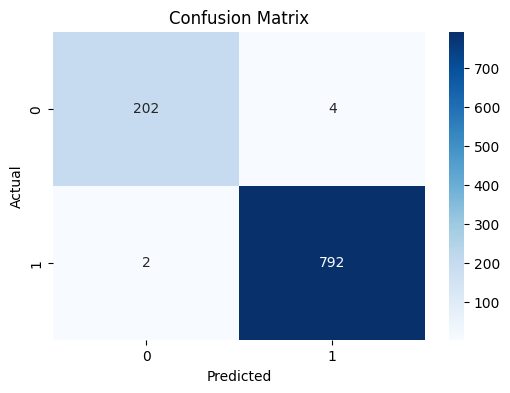

In [37]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

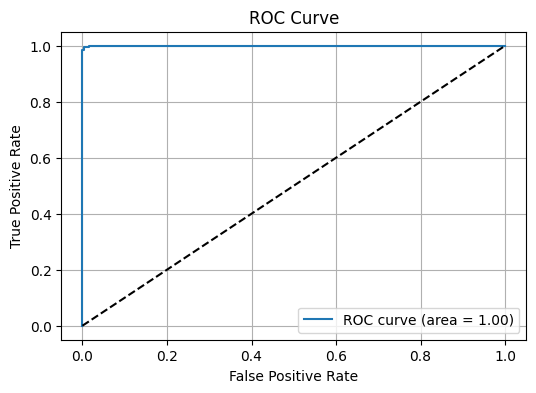

In [38]:
# ROC Curve plot
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.legend()
plt.grid()
plt.show()

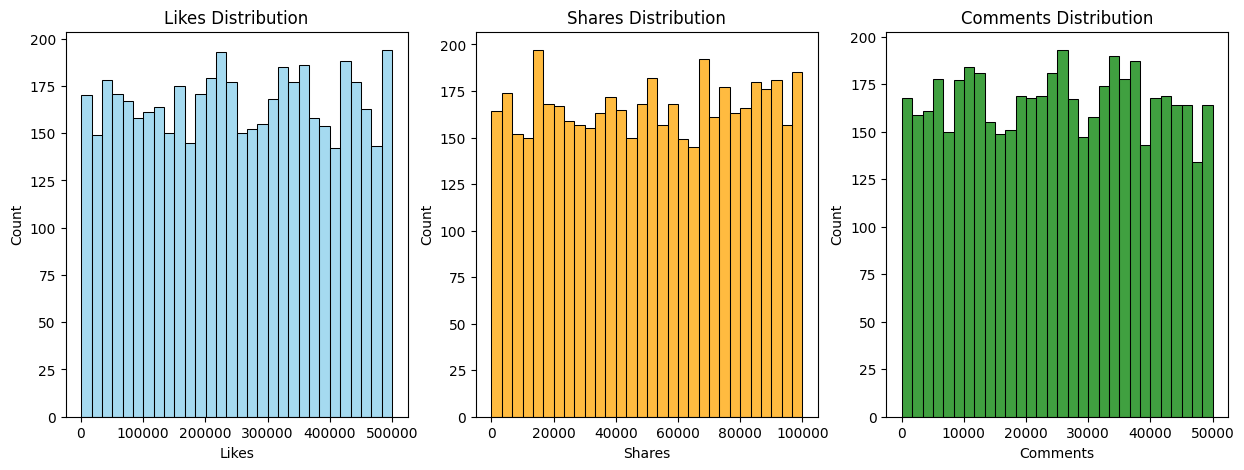

In [39]:
data["Total_Engagement"] = data["Likes"] + data["Shares"] + data["Comments"]

fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.histplot(data["Likes"], bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("Likes Distribution")
sns.histplot(data["Shares"], bins=30, ax=axes[1], color="orange")
axes[1].set_title("Shares Distribution")
sns.histplot(data["Comments"], bins=30, ax=axes[2], color="green")
axes[2].set_title("Comments Distribution")
plt.show()

/tmp/ipykernel_3056/844387643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Platform", order=data["Platform"].value_counts().index, palette="coolwarm")


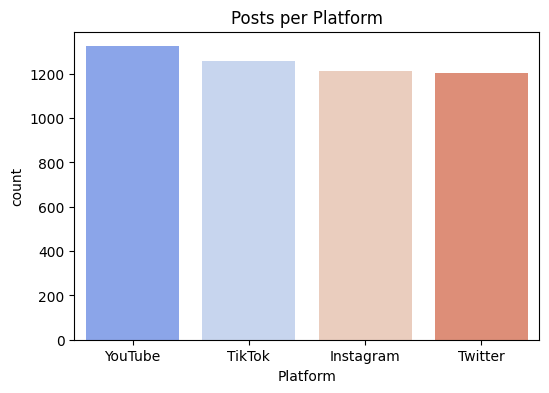

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Platform", order=data["Platform"].value_counts().index, palette="coolwarm")
plt.title("Posts per Platform")
plt.show()

/tmp/ipykernel_3056/3744598910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.values, y=region_counts.index, palette="mako")


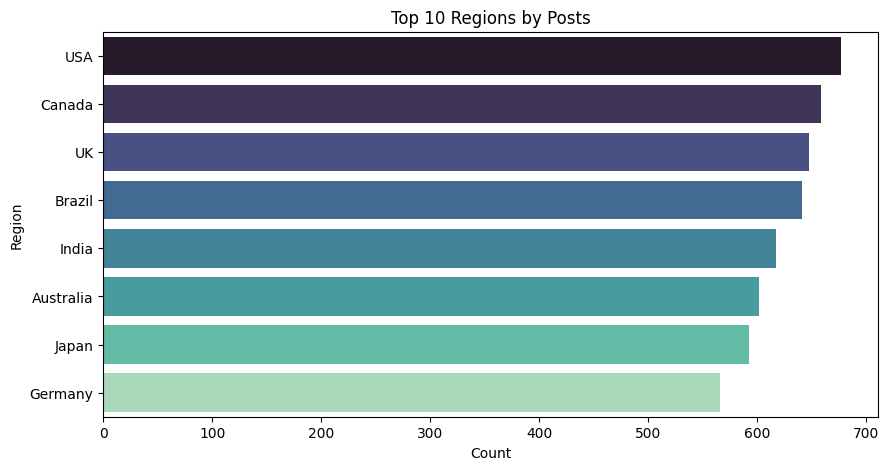

In [41]:
plt.figure(figsize=(10,5))
region_counts = data["Region"].value_counts().head(10)
sns.barplot(x=region_counts.values, y=region_counts.index, palette="mako")
plt.title("Top 10 Regions by Posts")
plt.xlabel("Count")
plt.show()

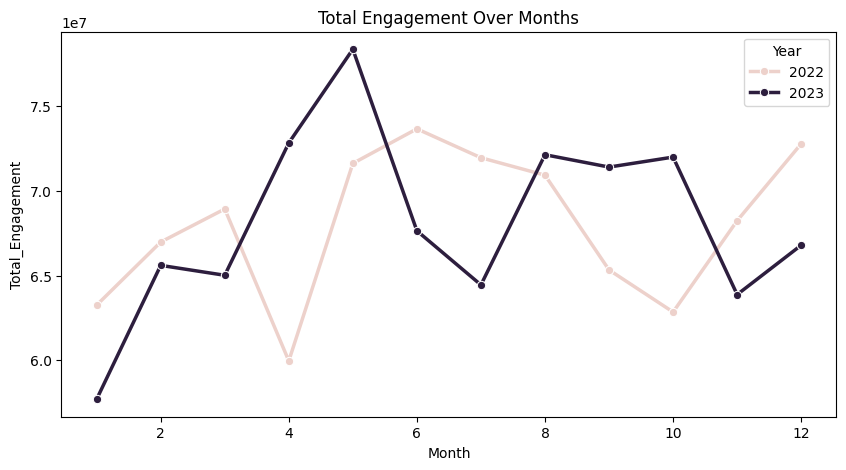

In [42]:
data["Post_Date"] = pd.to_datetime(data["Post_Date"], errors="coerce")
data = data.dropna(subset=["Post_Date"])
data["Year"] = data["Post_Date"].dt.year
data["Month"] = data["Post_Date"].dt.month

monthly_trends = data.groupby(["Year","Month"])["Total_Engagement"].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_trends, x="Month", y="Total_Engagement", hue="Year", marker="o", linewidth=2.5)
plt.title("Total Engagement Over Months")
plt.show()

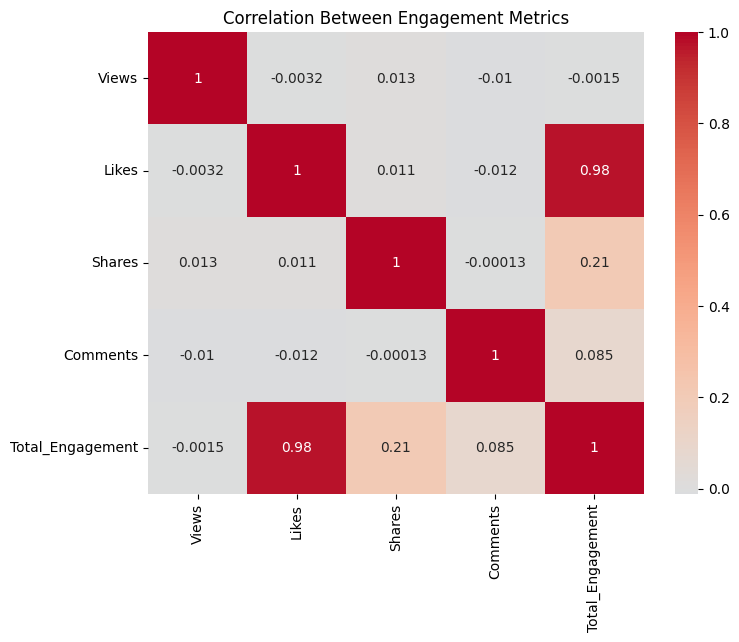

In [43]:
plt.figure(figsize=(8,6))
corr = data[["Views","Likes","Shares","Comments","Total_Engagement"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Engagement Metrics")
plt.show()